<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/03_Redes_neuronales_artificiales/mlp_optim.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:  Análisis de datos                             #
# Tópico: MLP con mini-batch SGD y optimizadores        #
#########################################################

Carga bibliotecas necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Entrenamiento MLP con mini-batch SGD y optimizadores

In [ ]:
sigmoid = lambda x: 1 / (1 + np.exp(-x)) # Sigmoid activation function
softmax = lambda x: np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True) # Softmax function
ce = lambda t, z: -np.sum(t * np.log(z + np.finfo(float).eps), axis=1)  # Cross-entropy loss function

# MLP trained by SGD
def mlp_train(X, Y, h, eta, l, nb, epochMax, patience, opt):
    Y = Y.reshape(-1, 1)
    c = len(np.unique(Y))
    # Split into training and validation sets
    X, Xv, Y, Yv = train_test_split(X, Y, test_size=0.2, random_state=42)
    n, d = X.shape
    tk = (Y == np.arange(c)).astype(float)   # Actual outputs in one-hot encoding
    X = np.hstack((np.ones((n, 1)), X)) # Add dummy inputs for the biases calculation
    nv = Xv.shape[0]
    tv = (Yv == np.arange(c)).astype(float)  # Actual outputs in one-hot encoding
    Xv = np.hstack((np.ones((nv, 1)), Xv)) # Add dummy inputs for the biases calculation
    # Weights initialization
    rd = lambda a, b, s, t: a + (b - a) * np.random.rand(s, t) # Xavier initialization
    Wji = rd(-np.sqrt(6 / (d + h)), np.sqrt(6 / (d + h)), h, d + 1) # Input-hidden layer weights
    Wkj = rd(-np.sqrt(6 / (h + c)), np.sqrt(6 / (h + c)), c, h + 1) # Hidden-output layer weights
    # Save the current model
    Wjibest = Wji
    Wkjbest = Wkj
    # Moment initialization and parameters
    if opt.lower() in ['momentum', 'adagrad', 'rmsprop']:
        alpha = 0.9                 # Momentum factor
        eps = 1e-8                  # Small value
        Vji = np.zeros((h, d + 1))
        Vkj = np.zeros((c, h + 1))
    elif opt.lower() == 'adam':
        beta1 = 0.9                 # Decay factor 1st moment
        beta2 = 0.999               # Decay factor 2nd moment
        eps = 1e-8                  # Small value
        Vji = np.zeros((h, d + 1))
        Mji = np.zeros((h, d + 1))
        Vkj = np.zeros((c, h + 1))
        Mkj = np.zeros((c, h + 1))
    # Training loop
    B, nbatch = batchify(n, nb)     # Split dataset into mini-batches
    Jt = np.zeros(epochMax)         # Save loss function
    Jv = np.zeros(epochMax)
    for t in range(epochMax):
        Jt[t] = loss(X, tk, Wji, Wkj, l)    # Learning loss
        Jv[t] = loss(Xv, tv, Wji, Wkj, l)   # Validation loss
        # Check early stopping
        if t > patience:
            if Jv[t] < Jv[t - patience]:  # Loss reduces
                Wjibest = Wji             # Save current best
                Wkjbest = Wkj
            else:
                Jt = Jt[:t]               # Cut learning curves to current epoch
                Jv = Jv[:t]
                print(f"Early stopping at epoch {t}")
                return Wjibest, Wkjbest, Jt, Jv, t
        else:
            Wjibest = Wji
            Wkjbest = Wkj
        # Shuffle data every epoch
        X, tk = shuffle(X, tk, n)
        for b in range(1, nbatch + 1):
            idx = (B == b)
            Xb = X[idx, :]
            tb = tk[idx, :]
            # Compute gradients
            Dwji, Dwkj = deltaRules(Xb, tb, Wji, Wkj)
            # Weight updates
            if opt.lower() == 'sgd':
                Wji = (1 - eta * l) * Wji - eta * Dwji  # Input-hidden
                Wkj = (1 - eta * l) * Wkj - eta * Dwkj  # Hidden-output
            elif opt.lower() == 'momentum':
                Vji = alpha * Vji + (1 - alpha) * Dwji
                Wji = (1 - eta * l) * Wji - eta * Vji
                Vkj = alpha * Vkj + (1 - alpha) * Dwkj
                Wkj = (1 - eta * l) * Wkj - eta * Vkj
            elif opt.lower() == 'adagrad':
                Vji += Dwji * Dwji
                Wji = (1 - eta * l) * Wji - (eta / (np.sqrt(Vji) + eps)) * Dwji
                Vkj += Dwkj * Dwkj
                Wkj = (1 - eta * l) * Wkj - (eta / (np.sqrt(Vkj) + eps)) * Dwkj
            elif opt.lower() == 'rmsprop':
                Vji = alpha * Vji + (1 - alpha) * Dwji **2
                Wji = (1 - eta * l) * Wji - (eta / (np.sqrt(Vji) + eps)) * Dwji
                Vkj = alpha * Vkj + (1 - alpha) * Dwkj **2
                Wkj = (1 - eta * l) * Wkj - (eta / (np.sqrt(Vkj) + eps)) * Dwkj
            elif opt.lower() == 'adam':
                Mji = beta1 * Mji + (1 - beta1) * Dwji
                Vji = beta2 * Vji + (1 - beta2) * Dwji **2
                hMij = Mji / (1 - beta1 ** (t + 1))
                hVji = Vji / (1 - beta2 ** (t + 1))
                Wji = (1 - eta * l) * Wji - ((eta * hMij) / (np.sqrt(hVji) + eps))
                Mkj = beta1 * Mkj + (1 - beta1) * Dwkj
                Vkj = beta2 * Vkj + (1 - beta2) * Dwkj **2
                hMkj = Mkj / (1 - beta1 ** (t + 1))
                hVkj = Vkj / (1 - beta2 ** (t + 1))
                Wkj = (1 - eta * l) * Wkj - (eta * hMkj / (np.sqrt(hVkj) + eps))
    print(f"Training completed in {t} epochs")
    return Wjibest, Wkjbest, Jt, Jv, t

# Split dataset into mini-batches
def batchify(n, nb):
  B = np.zeros(n, dtype=int)
  p = 0
  c = 0
  while p < n:
      q = 0
      c += 1
      while p < n and q < nb:
          p += 1
          q += 1
          B[p - 1] = c
  return B, c

# Shuffle data
def shuffle(X, Y, n):
  idx = np.random.permutation(n)
  X = X[idx, :]
  Y = Y[idx, :]
  return X, Y

# Compute gradients
def deltaRules(X, tk, Wji, Wkj):
    # Forward
    yj = sigmoid(X @ Wji.T)                         # Hidden layer response
    yj = np.hstack((np.ones((X.shape[0], 1)), yj))  # Add dummy inputs
    zk = softmax(yj @ Wkj.T)                        # Output layer response
    # Backward
    h = Wji.shape[0]
    dk = zk - tk                        # Delta k
    Dwkj = dk.T @ yj                    # Delta rule hidden-output
    dj = (dk @ Wkj) * (yj * (1 - yj))   # Delta j
    Dwji = dj[:, 1:h + 1].T @ X         # Delta rule input-hidden
    return Dwji, Dwkj

# Compute loss
def loss(X, tk, Wji, Wkj, l):
    # Forward
    yj = sigmoid(X @ Wji.T)                               # Hidden layer response
    yj = np.hstack((np.ones((X.shape[0], 1)), yj))        # Add dummy inputs
    zk = softmax(yj @ Wkj.T)                              # Output layer response
    L2 = (l / 2) * (np.sum(Wji ** 2) + np.sum(Wkj ** 2))
    Jt = np.mean(ce(tk, zk)) + L2                         # Regularized cross-entropy loss
    return Jt

Predice con MLP

In [ ]:
def mlp_predict(X, Wji, Wkj):
    unos = np.ones((X.shape[0], 1))
    X = np.hstack((unos, X))                        # Add dummy inputs
    yj = sigmoid(X @ Wji.T)                         # Hidden layer response
    yj = np.hstack((unos, yj))                      # Add dummy inputs
    zk = softmax(yj @ Wkj.T)                        # Output layer response
    ypp = np.argmax(zk, axis=1, keepdims=True)  # Classification by maximum probability
    ypp = ypp.reshape(-1, 1) # Asegurar vector columna
    return ypp, zk

Entrenamiento y clasificación

In [ ]:
h = 20             # Hidden neurons
epochMax = 5000    # Number of training epochs
eta = 1e-3         # Learning rate
lam = 1e-8         # Regularization factor
nb = 8             # Batch size
patience = 10      # Patience
opt = "momentum" #@param ["sgd", "momentum", "adagrad", "rmsprop", "adam"]
Wji, Wkj, Jt, Jv, t = mlp_train(X_train, Y_train, h, eta, lam, nb, epochMax, patience, opt)
Y_pred, _ = mlp_predict(X_test, Wji, Wkj)

Early stopping at epoch 2922


Visualiza matriz de confusión y curva de aprendizaje

Exactitud: 0.967


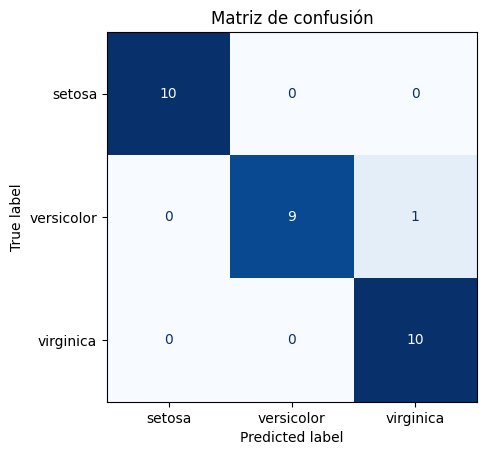

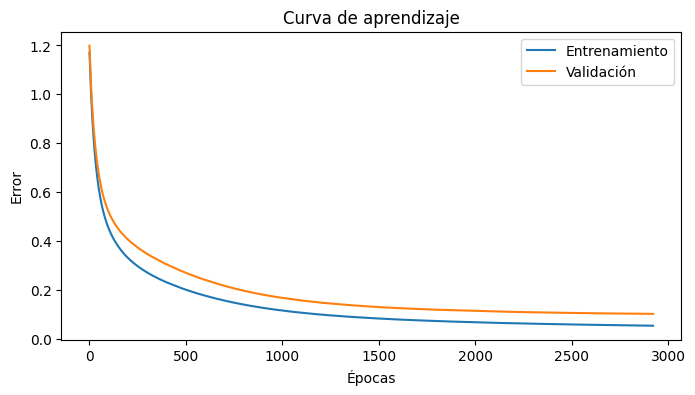

In [ ]:
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
print()
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, t + 1), Jt[:t], label="Entrenamiento")
plt.plot(np.arange(1, t + 1), Jv[:t], label="Validación")
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()